In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("../data/sepsis_clean.csv")
df.head()

,age,sex,episode,outcome
0,21,female,1,alive
1,20,female,1,alive
2,21,female,1,alive
3,77,male,1,alive
4,72,male,1,alive


In [3]:
#Survival Distribution (Target Variable)
df['outcome'].value_counts(normalize=True)*100

outcome
alive    92.645458
dead      7.354542
Name: proportion, dtype: float64

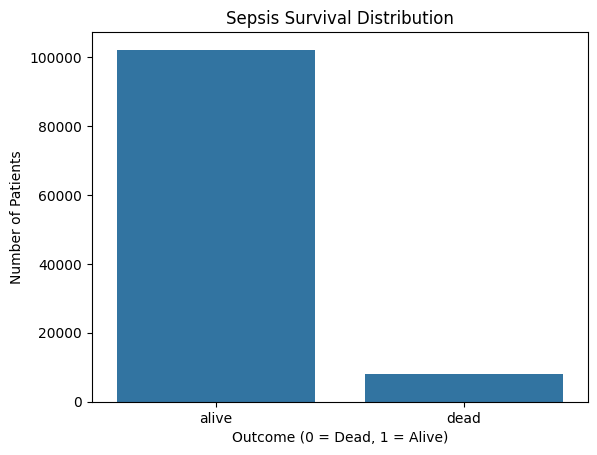

In [4]:
# Visualize the distribution of the target variable
sns.countplot(x='outcome', data=df)
plt.title("Sepsis Survival Distribution")
plt.xlabel("Outcome (0 = Dead, 1 = Alive)")
plt.ylabel("Number of Patients")
plt.show()

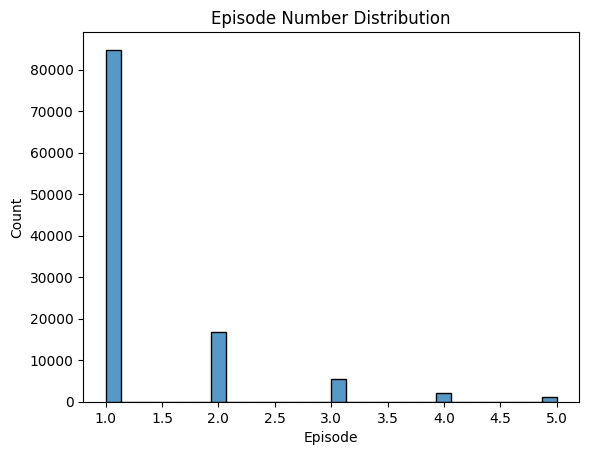

In [5]:
#Episode Distribution
sns.histplot(df['episode'], bins=30)
plt.title("Episode Number Distribution")
plt.xlabel("Episode")
plt.show()

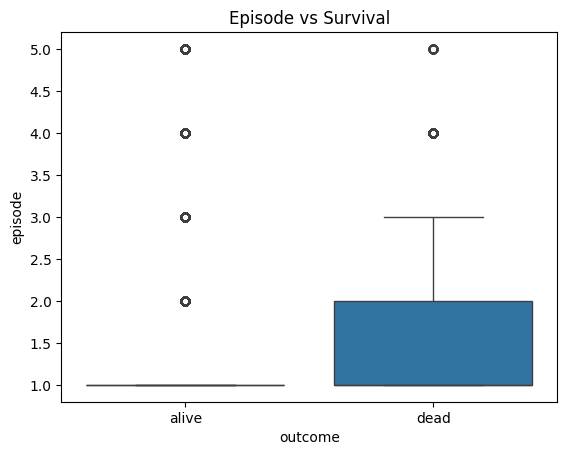

In [6]:
# Episode vs survival
sns.boxplot(x='outcome', y='episode', data=df)
plt.title("Episode vs Survival")
plt.show()

In [7]:
#create age groups

df['age_group'] = pd.cut(
    df['age'],
    bins=[0,18,40,60,80,100],
    labels=['0-18','18-40','40-60','60-80','80+']
)

In [8]:
df['age_group'].value_counts()

age_group
60-80    41645
80+      29420
40-60    19584
18-40    11327
0-18      6271
Name: count, dtype: int64

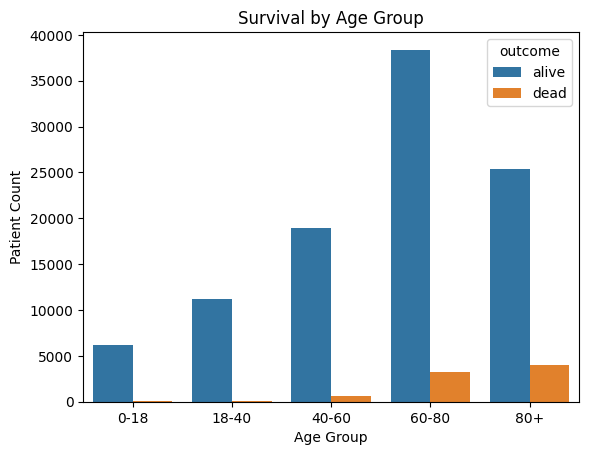

In [9]:
# Survival by agegroup 
sns.countplot(x='age_group', hue='outcome', data=df)
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")
plt.show()

In [10]:
df.dtypes

age             int64
sex            object
episode         int64
outcome        object
age_group    category
dtype: object

In [12]:
df['outcome'].unique()

array(['alive', 'dead'], dtype=object)

In [13]:
df['outcome'] = df['outcome'].map({
    'alive':1,
    'dead':0
})

In [14]:
df['outcome'].value_counts()

outcome
1    102099
0      8105
Name: count, dtype: int64

C:\Users\laksh\AppData\Local\Temp\ipykernel_12056\3596603538.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('age_group')['outcome'].mean()


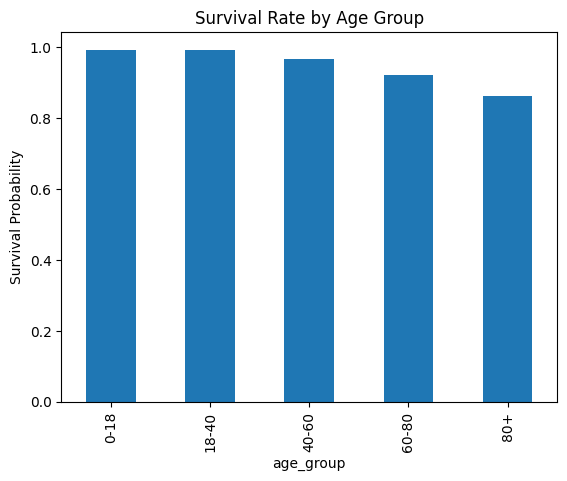

In [15]:
#Run Survival Analysis
age_survival = df.groupby('age_group')['outcome'].mean()

age_survival.plot(kind='bar')
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Probability")
plt.show()

In [17]:
#Class Imbalance Analysis
df['outcome'].value_counts(normalize=True) * 100

outcome
1    92.645458
0     7.354542
Name: proportion, dtype: float64

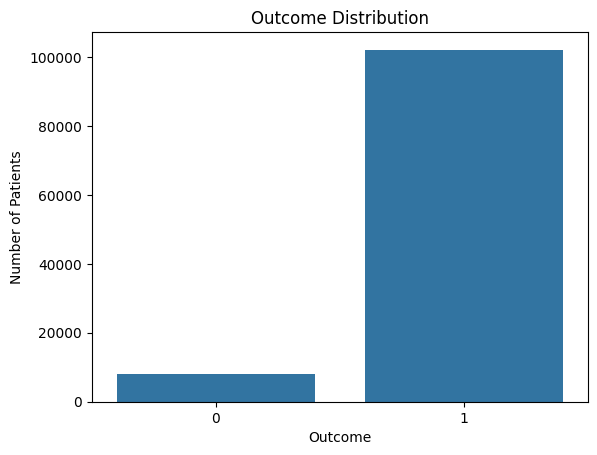

In [18]:
sns.countplot(x='outcome', data=df)

plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

Most patients survived while a smaller percentage died.
This indicates class imbalance, which may bias machine learning models toward predicting survival.
Techniques such as class weighting or resampling may be required during model training.

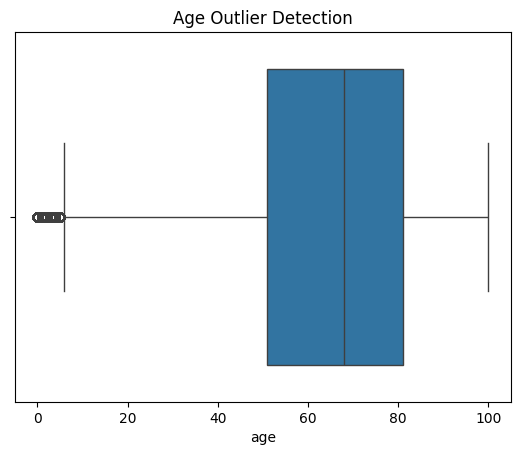

In [19]:
#Outlier Detection
sns.boxplot(x=df['age'])

plt.title("Age Outlier Detection")

plt.show()


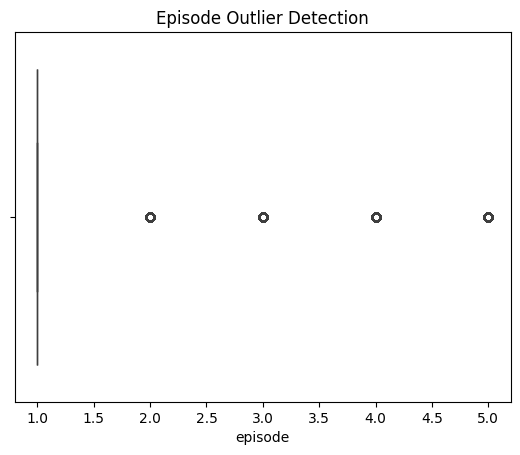

In [20]:
sns.boxplot(x=df['episode'])

plt.title("Episode Outlier Detection")

plt.show()

Most patients had only one sepsis episode

A small number had multiple episodes

In [21]:
#Save the file 
df.to_csv("../data/sepsis_EDA.csv", index=False)





0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
110199   NaN
110200   NaN
110201   NaN
110202   NaN
110203   NaN
Name: mortality, Length: 110204, dtype: float64